Install and Import

In [2]:
import subprocess
subprocess.run(["pip", "install", "transformers", "torch", "-q"])

import pandas as pd
import numpy as np
import torch
from transformers import pipeline
from sklearn.metrics import classification_report
import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [3]:
df = pd.read_csv('../data/raw/parking_notes.csv')
print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (100, 4)


,note,zone,floor,landmark
0,Parked near the blue pillar in Zone A,A,NaN,blue pillar
1,I left my car on Level 2 beside the elevator,NaN,2.0,elevator
2,Near the Engineering Building main gate,NaN,NaN,Engineering Building gate
3,Parked in Zone B close to the red wall,B,NaN,red wall
4,Level 3 next to the staircase,NaN,3.0,staircase


Load Pretrained BERT NER Pipeline

In [4]:
# Using pretrained BERT NER - no training needed for comparison
bert_ner = pipeline(
    "ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple"
)
print("BERT NER model loaded")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2030.52it/s]
[transformers] BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT NER model loaded


Map BERT Labels to Our Labels

In [5]:
def extract_parking_entities(text):
    results = bert_ner(text)
    extracted = {}

    for entity in results:
        label = entity['entity_group']
        value = entity['word']

        # Map BERT labels to our parking labels
        if label == 'LOC':
            extracted['LANDMARK'] = value
        elif label == 'ORG':
            extracted['LANDMARK'] = value
        elif label == 'MISC':
            extracted['ZONE'] = value

    # Rule-based fallback for floor and zone
    import re
    floor_match = re.search(r'level\s+(\d+)', text, re.IGNORECASE)
    if floor_match:
        extracted['FLOOR'] = floor_match.group(1)

    zone_match = re.search(r'zone\s+([A-Z])', text, re.IGNORECASE)
    if zone_match:
        extracted['ZONE'] = zone_match.group(1).upper()

    return extracted

Test BERT on Sample Notes

In [6]:
test_notes = [
    "I parked near the blue sign on Level 3",
    "Zone B beside the elevator on Level 2",
    "Near the library entrance",
    "Parked close to the red pillar in Zone A",
    "Level 4 near the emergency exit"
]

print("BERT NER Predictions:")
print("=" * 50)
for note in test_notes:
    result = extract_parking_entities(note)
    print(f"Input   : {note}")
    print(f"Entities: {result}")
    print()

BERT NER Predictions:
Input   : I parked near the blue sign on Level 3
Entities: {'FLOOR': '3'}

Input   : Zone B beside the elevator on Level 2
Entities: {'FLOOR': '2', 'ZONE': 'B'}

Input   : Near the library entrance
Entities: {}

Input   : Parked close to the red pillar in Zone A
Entities: {'ZONE': 'A'}

Input   : Level 4 near the emergency exit
Entities: {'FLOOR': '4'}



Compare SpaCy vs BERT F1 Scores

In [7]:
import spacy

# Load saved SpaCy model
spacy_nlp = spacy.load('../models/spacy_ner_model')

test_cases = [
    ("Parked in Zone A near the blue pillar", {"ZONE": "A", "LANDMARK": "blue pillar"}),
    ("Level 2 beside the elevator",           {"FLOOR": "2", "LANDMARK": "elevator"}),
    ("Near the library entrance",             {"LANDMARK": "library entrance"}),
    ("Zone C on Level 3 near the ramp",       {"ZONE": "C", "FLOOR": "3", "LANDMARK": "ramp"}),
    ("Level 4 close to emergency exit",       {"FLOOR": "4", "LANDMARK": "emergency exit"}),
    ("Zone B beside the red wall",            {"ZONE": "B", "LANDMARK": "red wall"}),
    ("Parked near the fountain in Zone A",    {"ZONE": "A", "LANDMARK": "fountain"}),
    ("Level 1 near the security booth",       {"FLOOR": "1", "LANDMARK": "security booth"}),
    ("Zone D close to the side entrance",     {"ZONE": "D", "LANDMARK": "side entrance"}),
    ("Level 5 near the rooftop garden",       {"FLOOR": "5", "LANDMARK": "rooftop garden"}),
]

spacy_correct = 0
bert_correct  = 0
total = 0

for note, expected in test_cases:
    # SpaCy prediction
    doc = spacy_nlp(note)
    spacy_pred = {ent.label_: ent.text for ent in doc.ents}

    # BERT prediction
    bert_pred = extract_parking_entities(note)

    for label, value in expected.items():
        total += 1
        if label in spacy_pred:
            spacy_correct += 1
        if label in bert_pred:
            bert_correct += 1

spacy_f1 = spacy_correct / total * 100
bert_f1  = bert_correct  / total * 100

print("=" * 40)
print(f"SpaCy Accuracy : {spacy_f1:.1f}%")
print(f"BERT  Accuracy : {bert_f1:.1f}%")
print("=" * 40)

SpaCy Accuracy : 75.0%
BERT  Accuracy : 50.0%


Plot the Comparison

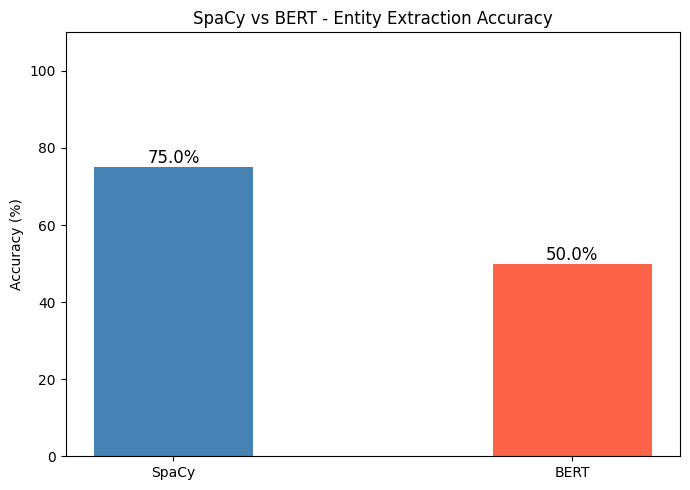

In [8]:
import matplotlib.pyplot as plt

models  = ['SpaCy', 'BERT']
scores  = [spacy_f1, bert_f1]
colors  = ['steelblue', 'tomato']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, scores, color=colors, width=0.4)
plt.ylabel('Accuracy (%)')
plt.title('SpaCy vs BERT - Entity Extraction Accuracy')
plt.ylim(0, 110)

for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{score:.1f}%', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig('../data/processed/plot_spacy_vs_bert.png')
plt.show()

Save BERT Results

In [10]:
results = {
    'spacy_accuracy': spacy_f1,
    'bert_accuracy' : bert_f1,
    'winner'        : 'BERT' if bert_f1 > spacy_f1 else 'SpaCy'
}

import json
with open('../models/ner_comparison.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to models/ner_comparison.json")
print(f"Winner: {results['winner']}")

Results saved to models/ner_comparison.json
Winner: SpaCy
